In [101]:
import pandas as pd
import numpy as np


In [102]:
beer = pd.read_csv('/content/russian_beers.csv')

In [103]:
beer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34334 entries, 0 to 34333
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brewery_name  34026 non-null  object 
 1   beer_name     34333 non-null  object 
 2   beer_style    34238 non-null  object 
 3   abv           33937 non-null  float64
 4   ibu           34334 non-null  int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 1.3+ MB


 **Для замены нулевых значений, которых большниство в столбце ibu, взял среднее по стилю напитка, где ibu изначально не 0. В результате, сравнив получившиеся средние значения и реальные значения для данного стиля, получил реалистичные числа из действительного диапазона.**

In [104]:
temp_ibu_mean = beer[beer.ibu != 0].groupby(['beer_style'])['ibu'].mean()

**Для замены Null в столбце abv так же взял среднее по стобцу для каждого стиля напитка, значения так же получились реалистичные**

In [105]:
temp_abv_mean = beer.groupby(['beer_style'])['abv'].mean()

In [107]:
print(temp_ibu_mean.isna().sum())
print(temp_abv_mean.isna().sum())

0
2


**В связи с тем, что остались пропуски, лучше заполнить их вручную, взяв открытые данные по сорту из интернета**

In [108]:
temp_abv_mean[temp_abv_mean.isna() == True]

,abv
beer_style,
Malt Beer,NaN
Rye Wine,NaN


In [109]:
temp_abv_mean['Malt Beer'] = 3
temp_abv_mean['Rye Wine'] = 12.5

**Здесь необходимо смержить все таблицы чтобы заменить null и нулевые значения**

In [112]:
beer_extended1 = beer.join(temp_abv_mean, on='beer_style', rsuffix='_mean')

In [113]:
beer = beer_extended1.join(temp_ibu_mean, on='beer_style', rsuffix='_mean')

In [114]:
beer

,brewery_name,beer_name,beer_style,abv,ibu,abv_mean,ibu_mean
0,NEW SCHOOL BREWERY,Тройная ИПА с хмелями цитра мозаика амарилло,IPA - Triple,10.0,0,9.183948,113.127551
1,NEW SCHOOL BREWERY,Smoothie Sour Ale Fruit Ball Манго feat. Клубника,Sour - Smoothie / Pastry,6.0,0,5.959173,9.185185
2,NEW SCHOOL BREWERY,Sour Ale Big Berries | Кислый эль с соками арб...,Sour - Fruited,6.5,0,5.922757,10.784336
3,NEW SCHOOL BREWERY,Triple IPA Strong Man | Тройная ИПА с хмелями ...,IPA - Triple,10.0,0,9.183948,113.127551
4,MULTTOWN BREW,Daily Horror,IPA - American,7.0,65,6.434358,53.212022
...,...,...,...,...,...,...,...
34329,BIG VILLAGE BREWERY,Ретроспектива,Barleywine - English,9.5,50,10.855625,41.880000
34330,MALANKA,Vir: Dźmuchaŭcy,American Wild Ale,5.5,0,6.395522,14.437500
34331,MAD FROG BREWERY,Wildest Harvest,American Wild Ale,5.8,0,6.395522,14.437500
34332,ŠVYTURYS,Memelbräu,Altbier,5.3,0,5.957143,36.416667


**Замена значени**

In [115]:
for i in range(len(beer)):

  if pd.isna(beer.loc[i, 'abv']):
    beer.loc[i, 'abv'] = beer.loc[i, 'abv_mean']
  if beer.loc[i, 'ibu'] == 0:
    beer.loc[i, 'ibu'] = beer.loc[i, 'ibu_mean']


/tmp/ipykernel_2078/3997906297.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '113.12755102040816' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  beer.loc[i, 'ibu'] = beer.loc[i, 'ibu_mean']


In [116]:
beer

,brewery_name,beer_name,beer_style,abv,ibu,abv_mean,ibu_mean
0,NEW SCHOOL BREWERY,Тройная ИПА с хмелями цитра мозаика амарилло,IPA - Triple,10.0,113.127551,9.183948,113.127551
1,NEW SCHOOL BREWERY,Smoothie Sour Ale Fruit Ball Манго feat. Клубника,Sour - Smoothie / Pastry,6.0,9.185185,5.959173,9.185185
2,NEW SCHOOL BREWERY,Sour Ale Big Berries | Кислый эль с соками арб...,Sour - Fruited,6.5,10.784336,5.922757,10.784336
3,NEW SCHOOL BREWERY,Triple IPA Strong Man | Тройная ИПА с хмелями ...,IPA - Triple,10.0,113.127551,9.183948,113.127551
4,MULTTOWN BREW,Daily Horror,IPA - American,7.0,65.000000,6.434358,53.212022
...,...,...,...,...,...,...,...
34329,BIG VILLAGE BREWERY,Ретроспектива,Barleywine - English,9.5,50.000000,10.855625,41.880000
34330,MALANKA,Vir: Dźmuchaŭcy,American Wild Ale,5.5,14.437500,6.395522,14.437500
34331,MAD FROG BREWERY,Wildest Harvest,American Wild Ale,5.8,14.437500,6.395522,14.437500
34332,ŠVYTURYS,Memelbräu,Altbier,5.3,36.416667,5.957143,36.416667


In [117]:
beer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34334 entries, 0 to 34333
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brewery_name  34026 non-null  object 
 1   beer_name     34333 non-null  object 
 2   beer_style    34238 non-null  object 
 3   abv           34328 non-null  float64
 4   ibu           33966 non-null  float64
 5   abv_mean      34238 non-null  float64
 6   ibu_mean      33951 non-null  float64
dtypes: float64(4), object(3)
memory usage: 1.8+ MB


**После всех замен остались Null значения, которые возникли из за отсутствия записей в beer_name и beer_style
Такие строки проще и лучше просто убрать**

In [118]:
beer.dropna(axis=0, inplace=True)

In [119]:
beer.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33642 entries, 0 to 34333
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brewery_name  33642 non-null  object 
 1   beer_name     33642 non-null  object 
 2   beer_style    33642 non-null  object 
 3   abv           33642 non-null  float64
 4   ibu           33642 non-null  float64
 5   abv_mean      33642 non-null  float64
 6   ibu_mean      33642 non-null  float64
dtypes: float64(4), object(3)
memory usage: 2.1+ MB


In [120]:
beer.drop(columns=['abv_mean', 'ibu_mean'], inplace=True)

In [121]:
beer

,brewery_name,beer_name,beer_style,abv,ibu
0,NEW SCHOOL BREWERY,Тройная ИПА с хмелями цитра мозаика амарилло,IPA - Triple,10.0,113.127551
1,NEW SCHOOL BREWERY,Smoothie Sour Ale Fruit Ball Манго feat. Клубника,Sour - Smoothie / Pastry,6.0,9.185185
2,NEW SCHOOL BREWERY,Sour Ale Big Berries | Кислый эль с соками арб...,Sour - Fruited,6.5,10.784336
3,NEW SCHOOL BREWERY,Triple IPA Strong Man | Тройная ИПА с хмелями ...,IPA - Triple,10.0,113.127551
4,MULTTOWN BREW,Daily Horror,IPA - American,7.0,65.000000
...,...,...,...,...,...
34329,BIG VILLAGE BREWERY,Ретроспектива,Barleywine - English,9.5,50.000000
34330,MALANKA,Vir: Dźmuchaŭcy,American Wild Ale,5.5,14.437500
34331,MAD FROG BREWERY,Wildest Harvest,American Wild Ale,5.8,14.437500
34332,ŠVYTURYS,Memelbräu,Altbier,5.3,36.416667


**Визуализация полученных данных на выявление выбросов**

In [122]:
from matplotlib import pyplot as plt


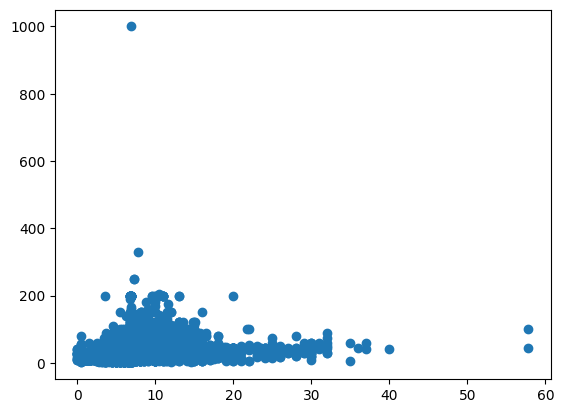

In [123]:
plt.scatter(x=beer.abv, y=beer.ibu)

In [124]:
print(beer[beer.ibu > 300])
print(beer[beer.abv > 50])

           brewery_name            beer_name               beer_style  abv  \
26537         MIKKELLER             1000 IBU             IPA - Triple  6.9   
29920  AROUND THE WORLD  From Ocean To Ocean  IPA - Imperial / Double  7.8   

          ibu  
26537  1000.0  
29920   330.0  
      brewery_name            beer_name                    beer_style   abv  \
18675      BREWDOG  Strength in Numbers         Freeze-distilled Beer  57.8   
23386      BREWDOG  Strength in Numbers  Bock - Eisbock (Traditional)  57.8   

              ibu  
18675   42.591549  
23386  100.000000  


In [125]:
beer.drop(index=[26537,29920,18675,23386], inplace=True)

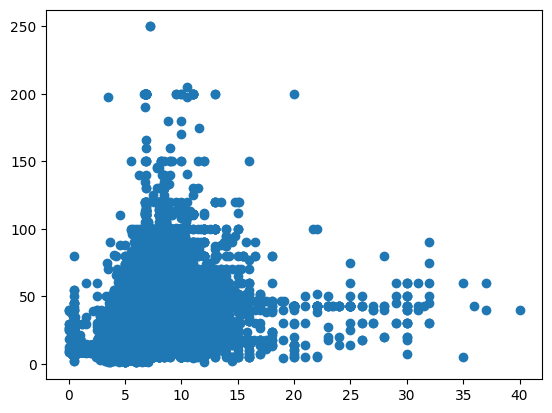

In [126]:
plt.scatter(x=beer.abv, y=beer.ibu)

In [127]:
beer.to_csv('beer_updated.csv')